In [2]:
import accelerate
import bitsandbytes
import peft
import trl

!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q trl peft accelerate bitsandbytes
!pip install -q rouge_score nltk bert_score evaluate matplotlib pandas

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments, EarlyStoppingCallback
import evaluate
from rouge_score import rouge_scorer
from bert_score import score as bert_score
MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"
MAX_SEQ_LEN = 512
MAX_SAMPLES = 30000
OUTPUT_DIR = "/content/"

In [6]:
print("Loading model with Unsloth optimizations...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

print(f"Model loaded. GPU memory used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

Loading model with Unsloth optimizations...
==((====))==  Unsloth 2026.3.18: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.18 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded. GPU memory used: 1.18 GB


In [13]:
print("Loading and formatting dataset...")
dataset = load_dataset("Abhishekcr448/Hinglish-Everyday-Conversations-1M", split="train")

# Shuffle and select a subset
dataset = dataset.shuffle(seed=42).select(range(MAX_SAMPLES))

# Format to Qwen ChatML
def format_chatml(examples):
    texts = []
    for instr, out in zip(examples["input"], examples["output"]):
        text = tokenizer.apply_chat_template([
            {"role": "user", "content": instr},
            {"role": "assistant", "content": out}
        ], tokenize=False, add_generation_prompt=False)
        texts.append(text)
    return { "text" : texts }

dataset = dataset.map(format_chatml, batched=True)
dataset = dataset.train_test_split(test_size=0.05, seed=42)

print(f"Train size: {len(dataset['train'])} | Eval size: {len(dataset['test'])}")

Loading and formatting dataset...


Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Train size: 28500 | Eval size: 1500


In [17]:
training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    per_device_train_batch_size = 4,
    gradient_accumulation_steps = 4,
    warmup_ratio = 0.05,
    num_train_epochs = 1,
    learning_rate = 2e-4,
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    logging_steps = 25,
    optim = "adamw_8bit",
    weight_decay = 0.01,
    lr_scheduler_type = "cosine",
    save_strategy = "steps",
    save_steps = 200,
    eval_strategy = "steps",
    eval_steps = 200,
    load_best_model_at_end = True,
    report_to = "none"
)
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset["train"],
    eval_dataset = dataset["test"],
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LEN,
    args = training_args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting training...")
trainer.train()
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Training complete and model saved!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/28500 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1500 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting training...


...

Step,Training Loss,Validation Loss
200,1.594374,1.522785
400,1.405987,1.393629
600,1.345346,1.317860
800,1.260913,1.264419
1000,1.243448,1.221231
1200,1.228033,1.192375


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Step,Training Loss,Validation Loss
200,1.594374,1.522785
400,1.405987,1.393629
600,1.345346,1.317860
800,1.260913,1.264419
1000,1.243448,1.221231
1200,1.228033,1.192375
1400,1.195857,1.170866
1600,1.186804,1.161597


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Training complete and model saved!


In [6]:

FastLanguageModel.for_inference(model)

eval_df = dataset["test"].select(range(50)).to_pandas()

def generate_response(prompt_text):

    user_text = prompt_text.split("<|im_start|>user\n")[1].split("<|im_end|>")[0]

    formatted_prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_text}],
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer([formatted_prompt], return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id
    )

    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response

print("Generating predictions for metrics...")
eval_df["predicted"] = eval_df["text"].apply(generate_response)
eval_df["reference"] = eval_df["response"]

display(eval_df[["instruction", "predicted", "reference"]].head())

Generating predictions for metrics...



,instruction,predicted,reference
0,Discount hai kya?,Haan ji! Abhi 20% off chal raha hai selected p...,"Haan, abhi discount available hai selected ite..."
1,Best phone suggest karo under 20k,"Agar aap 20k ke under dekh rahe ho, toh yeh ph...",20k ke andar yeh phone ek achha option hai.
2,Delivery kitne din me aayegi?,Usually 3-5 working days me delivery ho jati h...,Delivery 3-5 din ke andar ho jati hai.
3,Return possible hai kya?,Bilkul! 7 days easy return policy hai Agar pa...,"Haan, 7 din ke andar return kar sakte hain."
4,Quality kaisi hai?,Quality ekdum premium hai Customers ka feedba...,Product ki quality achhi hai.


        MODEL EVALUATION DASHBOARD

🔹 Generation Metrics:
BERTScore F1 : 0.8702
ROUGE-1 F1   : 0.6571
ROUGE-L F1   : 0.6038

🔹 Classification Metrics:
Accuracy     : 0.8840
Precision    : 0.8681
Recall       : 0.8696
F1 Score     : 0.8689

🔹 ROC-AUC:
AUC Score    : 0.4618


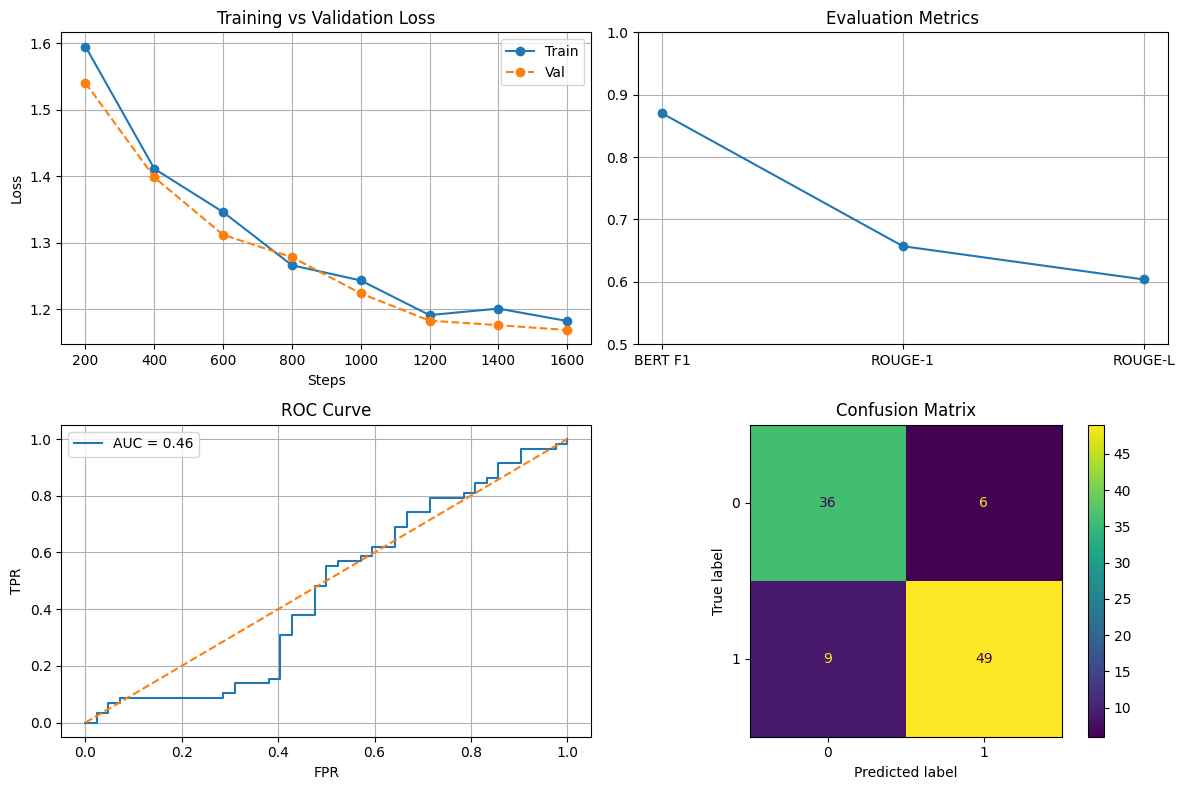


✅ Evaluation Completed Successfully!


In [9]:
print("Calculating BERTScore...")
preds = eval_df["predicted"].tolist()
refs = eval_df["reference"].tolist()

# Using the bert_score function imported earlier
P, R, F1 = bert_score(preds, refs, lang="en", verbose=False)

print("Calculating ROUGE...")
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
r1_f, rL_f = [], []

for p, r in zip(preds, refs):
    scores = scorer.score(r, p)
    r1_f.append(scores["rouge1"].fmeasure)
    rL_f.append(scores["rougeL"].fmeasure)

print("=" * 40)
print("EVALUATION METRICS SUMMARY")
print("=" * 40)
print(f"BERTScore F1 : {F1.mean().item():.4f}")
print(f"ROUGE-1 F1   : {np.mean(r1_f):.4f}")
print(f"ROUGE-L F1   : {np.mean(rL_f):.4f}")

# Quick plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["BERT F1", "ROUGE-1", "ROUGE-L"], [F1.mean().item(), np.mean(r1_f), np.mean(rL_f)], color=['steelblue', 'darkorange', 'mediumseagreen'])
ax.set_ylim(0, 1)
ax.set_title("Model Performance on Hinglish")
plt.show()

In [11]:
test_prompts = [
    "Kya aap mujhe bata sakte ho ki Python mein list kaise banate hain?",
    "Mera phone bahut slow ho gaya hai, kya karu?",
    "Kal mujhe interview hai, kuch tips doge?"
]

print("=" * 60)
print(" QUALITATIVE INFERENCE EXAMPLES")
print("=" * 60)
for i, prompt in enumerate(test_prompts, 1):
    # Format properly for inference
    formatted = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer([formatted], return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.7, pad_token_id=tokenizer.eos_token_id)
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    print(f"\n[{i}] User      : {prompt}")
    print(f"    Assistant : {response}")
    print("-" * 60)

 QUALITATIVE INFERENCE EXAMPLES

[1] User      : Kya aap mujhe bata sakte ho ki Python mein list kaise banate hain?
    Assistant : Haan bilkul! Python mein list banane ke liye aap square brackets use karte ho. Example: my_list = [1, 2, 3]. Isme aap multiple values store kar sakte ho.
------------------------------------------------------------

[2] User      : Mera phone bahut slow ho gaya hai, kya karu?
    Assistant : Agar phone slow ho gaya hai toh pehle unnecessary apps uninstall karo, cache clear karo aur background apps band karo. Agar fir bhi slow hai toh restart ya reset try kar sakte ho.
------------------------------------------------------------

[3] User      : Kal mujhe interview hai, kuch tips doge?
    Assistant : All the best! Interview ke liye confident raho, basics clear rakho aur answers simple aur clear dene ki koshish karo. Practice karo aur calm rehna 
------------------------------------------------------------
